In [2]:
import os
import json
import statistics

from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




In [3]:
BASE_DIR = "/home/kaiju/melissa_dev/ai-ed"
EVAL_DIR = "base-scoring-outputs/evals"
EVAL_FILE = os.path.join(BASE_DIR, EVAL_DIR, "calcuated_eval_2025-04-07-17-52.tsv")
date_str = datetime.now().strftime("%Y-%m-%d-%H-%M")

df = pd.read_csv(EVAL_FILE, sep="\t")

df.head()

,idx,essay_id,essay_set,essay,comments,domain1_score_pred_org,domain2_score_pred_org,domain1_score_gt,domain2_score_gt,domain1_score_pred_total,domain2_score_pred_total,mse_domain1,mse_domain2
0,0,1,1,"Dear local newspaper, I think effects computer...","After reviewing the essay and the rubric, I wo...",3.0,0.0,8.0,0.0,6.0,0.0,4.0,0.0
1,1,2,1,"Dear @CAPS1 @CAPS2, I believe that using compu...","Based on the provided essay, I would assign a ...",3.0,0.0,9.0,0.0,6.0,0.0,9.0,0.0
2,2,3,1,"Dear, @CAPS1 @CAPS2 @CAPS3 More and more peopl...","Based on the provided essay and rubric, I have...",2.0,0.0,7.0,0.0,4.0,0.0,9.0,0.0
3,3,4,1,"Dear Local Newspaper, @CAPS1 I have found that...","Based on the provided rubric and essay, I woul...",4.0,0.0,10.0,0.0,8.0,0.0,4.0,0.0
4,4,5,1,"Dear @LOCATION1, I know having computers has a...","Based on the provided essay and the rubric, I ...",3.0,0.0,8.0,0.0,6.0,0.0,4.0,0.0


In [4]:

plot_df = df[[
    "essay_id",
    "essay_set",
    "domain1_score_gt", 
    "domain2_score_gt", 
    "domain1_score_pred_total",
    "domain2_score_pred_total"]]

plot_df.head()

,essay_id,essay_set,domain1_score_gt,domain2_score_gt,domain1_score_pred_total,domain2_score_pred_total
0,1,1,8.0,0.0,6.0,0.0
1,2,1,9.0,0.0,6.0,0.0
2,3,1,7.0,0.0,4.0,0.0
3,4,1,10.0,0.0,8.0,0.0
4,5,1,8.0,0.0,6.0,0.0


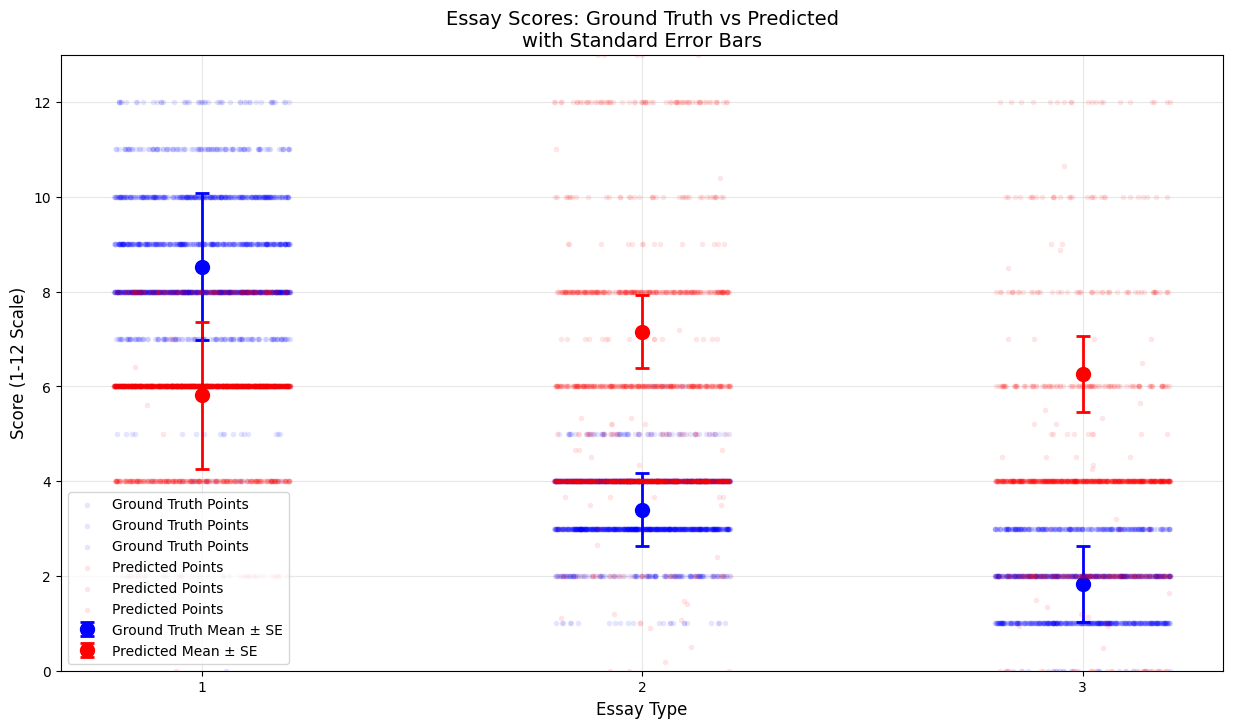

In [32]:
# Create a clear figure with larger size
plt.figure(figsize=(15, 8))

# Calculate mean, std, and count for each essay
summary_stats = plot_df.groupby('essay_set').agg({
    'domain1_score_gt': ['mean', 'std', 'count'],
    'domain1_score_pred_total': ['mean', 'std', 'count']
}).reset_index()

# Calculate standard error
summary_stats['gt_stderr'] = summary_stats['domain1_score_gt']['std']
summary_stats['pred_stderr'] = summary_stats['domain1_score_gt']['std']

# Create x-positions based on unique essay sets
x_positions = summary_stats['essay_set'].values - 1  # Subtract 1 to align with 0-based indexing

# Plot individual points with some jitter and transparency
sns.stripplot(data=plot_df, x='essay_set', y='domain1_score_gt',
              color='blue', alpha=0.1, label='Ground Truth Points', 
              jitter=0.2, size=4)
sns.stripplot(data=plot_df, x='essay_set', y='domain1_score_pred_total',
              color='red', alpha=0.1, label='Predicted Points', 
              jitter=0.2, size=4)

# Add error bars with corrected x-positions
plt.errorbar(x=x_positions, 
            y=summary_stats[('domain1_score_gt', 'mean')],
            yerr=summary_stats['gt_stderr'],
            fmt='o', color='blue', capsize=5, capthick=2, 
            markersize=10, label='Ground Truth Mean ± SE',
            elinewidth=2)

plt.errorbar(x=x_positions, 
            y=summary_stats[('domain1_score_pred_total', 'mean')],
            yerr=summary_stats['pred_stderr'],
            fmt='o', color='red', capsize=5, capthick=2, 
            markersize=10, label='Predicted Mean ± SE',
            elinewidth=2)

# Customize the plot
plt.xlabel('Essay Type', fontsize=12)
plt.ylabel('Score (1-12 Scale)', fontsize=12)
plt.title('Essay Scores: Ground Truth vs Predicted\nwith Standard Error Bars', fontsize=14)
plt.legend(fontsize=5)
plt.grid(True, alpha=0.3)
plt.ylim(0, 13)

# Set x-ticks to show correct essay set numbers
plt.xticks(x_positions, summary_stats['essay_set'])

plt.show()